In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

df = pd.read_csv('data/house_prices/train.csv')
print('Shape:', df.shape)

# SECTION 1: Overview
df.info(); 
print(df.describe().round(1))

Shape: (1460, 81)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   object 
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   object 
 6   Alley          91 non-null     object 
 7   LotShape       1460 non-null   object 
 8   LandContour    1460 non-null   object 
 9   Utilities      1460 non-null   object 
 10  LotConfig      1460 non-null   object 
 11  LandSlope      1460 non-null   object 
 12  Neighborhood   1460 non-null   object 
 13  Condition1     1460 non-null   object 
 14  Condition2     1460 non-null   object 
 15  BldgType       1460 non-null   object 
 16  HouseStyle     1460 non-null   object 
 17  OverallQual    1460 non-null   int

PoolQC          99.520548
MiscFeature     96.301370
Alley           93.767123
Fence           80.753425
MasVnrType      59.726027
FireplaceQu     47.260274
LotFrontage     17.739726
GarageQual       5.547945
GarageFinish     5.547945
GarageType       5.547945
GarageYrBlt      5.547945
GarageCond       5.547945
BsmtFinType2     2.602740
BsmtExposure     2.602740
BsmtCond         2.534247
BsmtQual         2.534247
BsmtFinType1     2.534247
MasVnrArea       0.547945
Electrical       0.068493
dtype: float64
        Column  Null_Percentage
0       PoolQC        99.520548
1  MiscFeature        96.301370
2        Alley        93.767123
3        Fence        80.753425
4   MasVnrType        59.726027


<Axes: xlabel='Null_Percentage', ylabel='Column'>

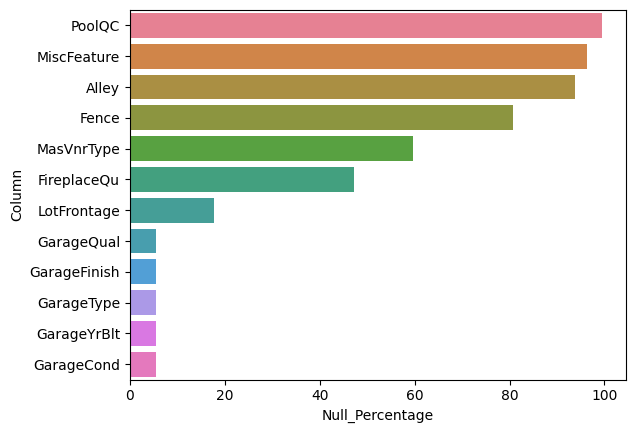

In [2]:
# SECTION 2: Missing values
null_pct = (df.isnull().sum() / len(df) * 100).sort_values(ascending=False)
print(null_pct[null_pct > 0])
# TODO: Plot bar chart of null percentages
null_pct_df = pd.DataFrame(null_pct[null_pct > 5])
null_pct_df = null_pct_df.reset_index()
null_pct_df.columns = ['Column', 'Null_Percentage']
print(null_pct_df.head())
sns.barplot(x= 'Null_Percentage', y = 'Column' ,data=null_pct_df, hue='Column' ,legend=False)

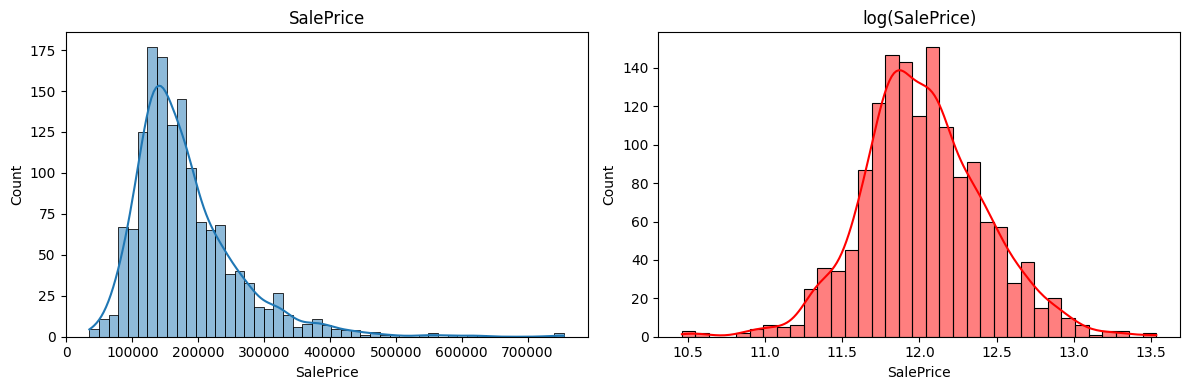

In [3]:
# SECTION 3: Target analysis
fig, ax = plt.subplots(1, 2, figsize=(12,4))
sns.histplot(df['SalePrice'], kde=True, ax=ax[0])
sns.histplot(np.log1p(df['SalePrice']), kde=True, ax=ax[1], color='red')
ax[0].set_title('SalePrice'); ax[1].set_title('log(SalePrice)')
plt.tight_layout(); 
plt.show()

In [4]:
# SECTION 4: Top correlations
top = df.select_dtypes(include='number').corr()['SalePrice'].abs().sort_values(ascending=False).head(11)
print(top)

SalePrice       1.000000
OverallQual     0.790982
GrLivArea       0.708624
GarageCars      0.640409
GarageArea      0.623431
TotalBsmtSF     0.613581
1stFlrSF        0.605852
FullBath        0.560664
TotRmsAbvGrd    0.533723
YearBuilt       0.522897
YearRemodAdd    0.507101
Name: SalePrice, dtype: float64


OverallQual     0.795774
GrLivArea       0.734968
TotalBsmtSF     0.651153
GarageCars      0.641047
1stFlrSF        0.631530
GarageArea      0.629217
FullBath        0.562165
TotRmsAbvGrd    0.537769
YearBuilt       0.523608
YearRemodAdd    0.507717
Name: SalePrice, dtype: float64


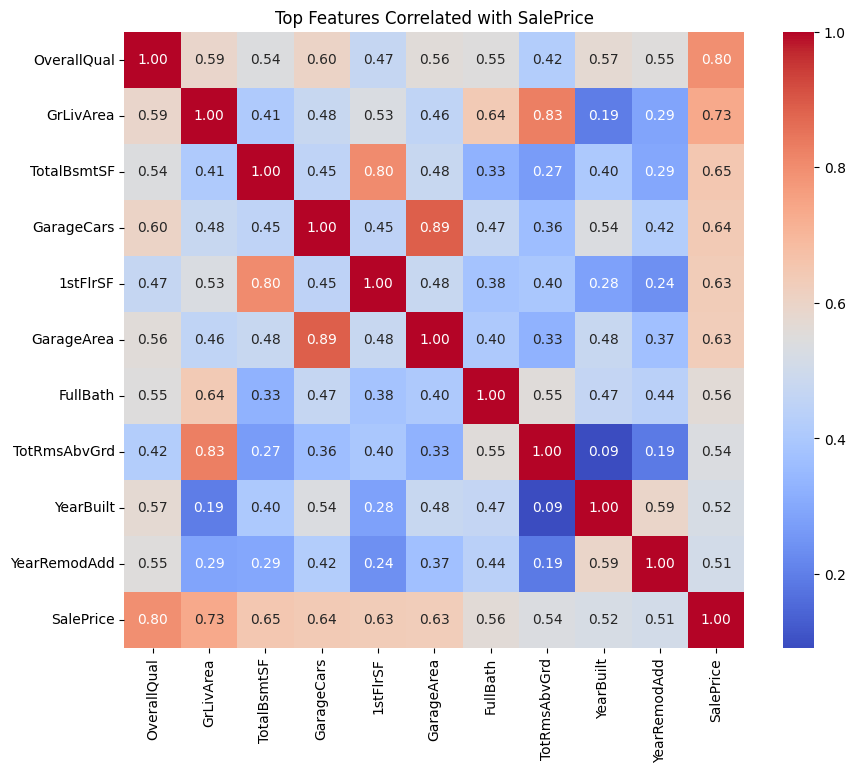

In [15]:
corr_with_target = df.corr(numeric_only=True)['SalePrice']
top_10_abs = (
    corr_with_target
    .drop('SalePrice')
    .abs()
    .sort_values(ascending=False)
    .head(10)
)

print(top_10_abs)

top_features = top_10_abs.index.tolist() + ['SalePrice']

plt.figure(figsize=(10,8))
sns.heatmap(
    df[top_features].corr(),
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)
plt.title('Top Features Correlated with SalePrice')
plt.show()

GrLivArea bounds: [159, 2748]
SalePrice bounds: [3938, 340038]
Outliers: 77 rows


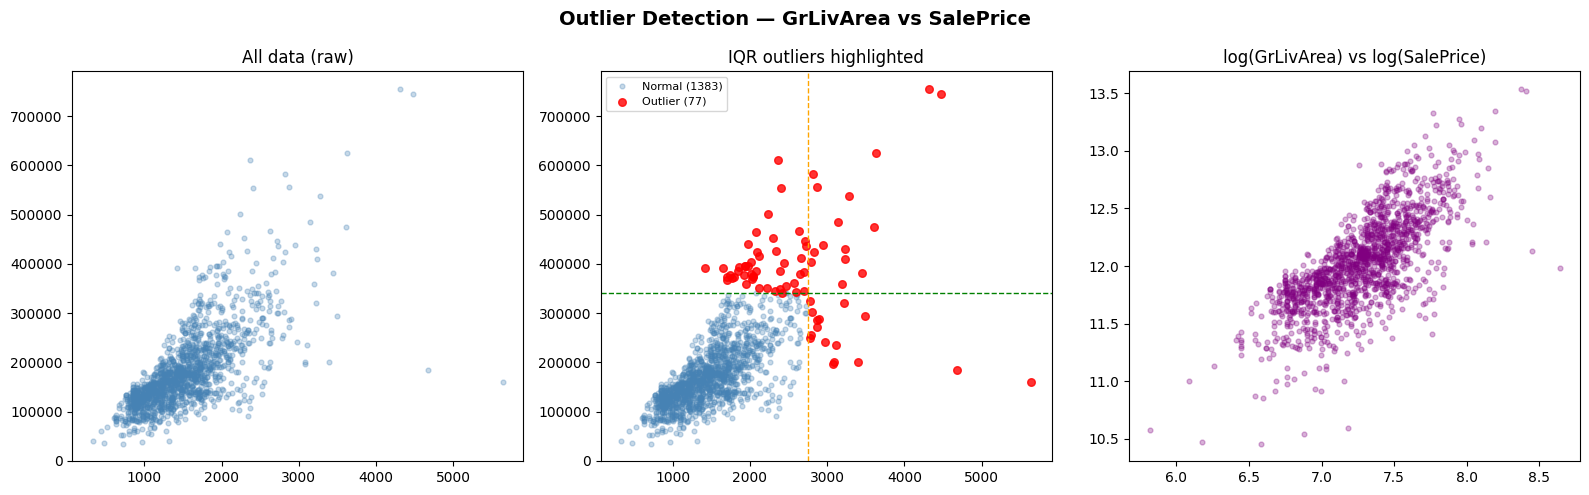


Top 5 GrLivArea outliers:
        Id  GrLivArea  SalePrice
1298  1299       5642     160000
523    524       4676     184750
1182  1183       4476     745000
691    692       4316     755000
1169  1170       3627     625000

Suspect rows (big house, low price): 2
        Id  GrLivArea  SalePrice
523    524       4676     184750
1298  1299       5642     160000

Final shape after removal: (1458, 81)


In [5]:

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# ── 1. IQR outlier flags ──────────────────────────────────
def iqr_bounds(series):
    Q1, Q3 = series.quantile(0.25), series.quantile(0.75)
    IQR = Q3 - Q1
    return Q1 - 1.5*IQR, Q3 + 1.5*IQR

liv_lo,   liv_hi   = iqr_bounds(df['GrLivArea'])
price_lo, price_hi = iqr_bounds(df['SalePrice'])

df['liv_outlier']   = (df['GrLivArea'] < liv_lo)  | (df['GrLivArea'] > liv_hi)
df['price_outlier'] = (df['SalePrice'] < price_lo) | (df['SalePrice'] > price_hi)
df['either_outlier'] = df['liv_outlier'] | df['price_outlier']

print(f'GrLivArea bounds: [{liv_lo:.0f}, {liv_hi:.0f}]')
print(f'SalePrice bounds: [{price_lo:.0f}, {price_hi:.0f}]')
print(f'Outliers: {df["either_outlier"].sum()} rows')

# ── 2. 3-panel scatter plot ───────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Outlier Detection — GrLivArea vs SalePrice',
             fontsize=14, fontweight='bold')

# Panel 1: raw
axes[0].scatter(df['GrLivArea'], df['SalePrice'],
                alpha=0.3, s=12, color='steelblue')
axes[0].set_title('All data (raw)')

# Panel 2: outliers highlighted red
clean    = df[~df['either_outlier']]
outliers = df[df['either_outlier']]
axes[1].scatter(clean['GrLivArea'],    clean['SalePrice'],
                alpha=0.3, s=12, color='steelblue',
                label=f'Normal ({len(clean)})')
axes[1].scatter(outliers['GrLivArea'], outliers['SalePrice'],
                alpha=0.8, s=30, color='red',
                label=f'Outlier ({len(outliers)})')
axes[1].axvline(liv_hi,   color='orange', ls='--', lw=1)
axes[1].axhline(price_hi, color='green',  ls='--', lw=1)
axes[1].set_title('IQR outliers highlighted')
axes[1].legend(fontsize=8)

# Panel 3: log-log (reduces visual dominance of outliers)
axes[2].scatter(np.log1p(df['GrLivArea']), np.log1p(df['SalePrice']),
                alpha=0.3, s=12, color='purple')
axes[2].set_title('log(GrLivArea) vs log(SalePrice)')

plt.tight_layout()
plt.savefig('charts/outlier_grliv_saleprice.png', dpi=150, bbox_inches='tight')
plt.show()

# ── 3. Print worst offenders ──────────────────────────────
print('\nTop 5 GrLivArea outliers:')
print(df.nlargest(5, 'GrLivArea')[['Id','GrLivArea','SalePrice']])

# ── 4. Remove the 2 famous Kaggle outliers ───────────────
suspect = df[(df['GrLivArea'] > 4000) & (df['SalePrice'] < 200000)]
print(f'\nSuspect rows (big house, low price): {len(suspect)}')
print(suspect[['Id','GrLivArea','SalePrice']])

df = df[~((df['GrLivArea'] > 4000) & (df['SalePrice'] < 200000))]
df = df.drop(columns=['liv_outlier','price_outlier','either_outlier'])
print(f'\nFinal shape after removal: {df.shape}')

In [6]:
# SECTION 5: Feature Engineering TODOs
df_eng = df.copy()
# TODO 1: TotalSF = TotalBsmtSF + 1stFlrSF + 2ndFlrSF
df_eng['TotalSF'] = df_eng['TotalBsmtSF'] + df_eng['1stFlrSF'] + df_eng['2ndFlrSF']
print(df_eng.head())

   Id  MSSubClass MSZoning  LotFrontage  LotArea Street Alley LotShape  \
0   1          60       RL         65.0     8450   Pave   NaN      Reg   
1   2          20       RL         80.0     9600   Pave   NaN      Reg   
2   3          60       RL         68.0    11250   Pave   NaN      IR1   
3   4          70       RL         60.0     9550   Pave   NaN      IR1   
4   5          60       RL         84.0    14260   Pave   NaN      IR1   

  LandContour Utilities  ... PoolQC Fence MiscFeature MiscVal MoSold YrSold  \
0         Lvl    AllPub  ...    NaN   NaN         NaN       0      2   2008   
1         Lvl    AllPub  ...    NaN   NaN         NaN       0      5   2007   
2         Lvl    AllPub  ...    NaN   NaN         NaN       0      9   2008   
3         Lvl    AllPub  ...    NaN   NaN         NaN       0      2   2006   
4         Lvl    AllPub  ...    NaN   NaN         NaN       0     12   2008   

  SaleType  SaleCondition  SalePrice  TotalSF  
0       WD         Normal     20

In [7]:
# TODO 2: HouseAge = YrSold - YearBuilt
df_eng['HouseAge'] = df_eng['YrSold'] - df_eng['YearBuilt']
print(df_eng.head())

   Id  MSSubClass MSZoning  LotFrontage  LotArea Street Alley LotShape  \
0   1          60       RL         65.0     8450   Pave   NaN      Reg   
1   2          20       RL         80.0     9600   Pave   NaN      Reg   
2   3          60       RL         68.0    11250   Pave   NaN      IR1   
3   4          70       RL         60.0     9550   Pave   NaN      IR1   
4   5          60       RL         84.0    14260   Pave   NaN      IR1   

  LandContour Utilities  ... Fence MiscFeature MiscVal MoSold YrSold SaleType  \
0         Lvl    AllPub  ...   NaN         NaN       0      2   2008       WD   
1         Lvl    AllPub  ...   NaN         NaN       0      5   2007       WD   
2         Lvl    AllPub  ...   NaN         NaN       0      9   2008       WD   
3         Lvl    AllPub  ...   NaN         NaN       0      2   2006       WD   
4         Lvl    AllPub  ...   NaN         NaN       0     12   2008       WD   

  SaleCondition  SalePrice  TotalSF  HouseAge  
0        Normal     

In [8]:
# TODO 3: IsRemodelled = (YearRemodAdd != YearRemodAdd).astype(int)
df_eng['IsRemodelled'] = (df_eng['YearRemodAdd'] != df_eng['YearRemodAdd']).astype(int)
print(df_eng.tail())

        Id  MSSubClass MSZoning  LotFrontage  LotArea Street Alley LotShape  \
1455  1456          60       RL         62.0     7917   Pave   NaN      Reg   
1456  1457          20       RL         85.0    13175   Pave   NaN      Reg   
1457  1458          70       RL         66.0     9042   Pave   NaN      Reg   
1458  1459          20       RL         68.0     9717   Pave   NaN      Reg   
1459  1460          20       RL         75.0     9937   Pave   NaN      Reg   

     LandContour Utilities  ... MiscFeature MiscVal MoSold YrSold SaleType  \
1455         Lvl    AllPub  ...         NaN       0      8   2007       WD   
1456         Lvl    AllPub  ...         NaN       0      2   2010       WD   
1457         Lvl    AllPub  ...        Shed    2500      5   2010       WD   
1458         Lvl    AllPub  ...         NaN       0      4   2010       WD   
1459         Lvl    AllPub  ...         NaN       0      6   2008       WD   

     SaleCondition SalePrice  TotalSF  HouseAge  IsRemod

In [9]:
# TODO 4: TotalBaths = FullBath + 0.5*HalfBath + BsmtFullBath + 0.5*BsmtHalfBath
df_eng['TotalBaths'] = df_eng['FullBath'] + (df_eng['HalfBath']*0.5) + df_eng['BsmtFullBath'] + (df_eng['BsmtHalfBath']*0.5)
print(df_eng.tail())

        Id  MSSubClass MSZoning  LotFrontage  LotArea Street Alley LotShape  \
1455  1456          60       RL         62.0     7917   Pave   NaN      Reg   
1456  1457          20       RL         85.0    13175   Pave   NaN      Reg   
1457  1458          70       RL         66.0     9042   Pave   NaN      Reg   
1458  1459          20       RL         68.0     9717   Pave   NaN      Reg   
1459  1460          20       RL         75.0     9937   Pave   NaN      Reg   

     LandContour Utilities  ... MiscVal MoSold YrSold SaleType SaleCondition  \
1455         Lvl    AllPub  ...       0      8   2007       WD        Normal   
1456         Lvl    AllPub  ...       0      2   2010       WD        Normal   
1457         Lvl    AllPub  ...    2500      5   2010       WD        Normal   
1458         Lvl    AllPub  ...       0      4   2010       WD        Normal   
1459         Lvl    AllPub  ...       0      6   2008       WD        Normal   

     SalePrice TotalSF  HouseAge  IsRemodell

In [10]:
# TODO 5: Log-transform skewed numeric features
import numpy as np
numeric_cols = df_eng.select_dtypes(include=['int64', 'float64']).columns
skewness = df_eng[numeric_cols].skew()
skewed_features = skewness[skewness > 1].index

for col in skewed_features:
    df_eng[col] = np.log1p(df_eng[col])

print("Log transformed columns:")
print(list(skewed_features))

Log transformed columns:
['MSSubClass', 'LotFrontage', 'LotArea', 'MasVnrArea', 'BsmtFinSF2', 'LowQualFinSF', 'GrLivArea', 'BsmtHalfBath', 'KitchenAbvGr', 'WoodDeckSF', 'OpenPorchSF', 'EnclosedPorch', '3SsnPorch', 'ScreenPorch', 'PoolArea', 'MiscVal', 'SalePrice']


In [11]:
# TODO 6: Drop columns with >40% missing
missing_pct = df_eng.isnull().mean() * 100
cols_to_drop = missing_pct[missing_pct > 40].index

print("Columns to drop:")
print(list(cols_to_drop))

df_eng = df_eng.drop(columns=cols_to_drop)

print("\nRemaining columns:")
print(df_eng.columns)

Columns to drop:
['Alley', 'MasVnrType', 'FireplaceQu', 'PoolQC', 'Fence', 'MiscFeature']

Remaining columns:
Index(['Id', 'MSSubClass', 'MSZoning', 'LotFrontage', 'LotArea', 'Street',
       'LotShape', 'LandContour', 'Utilities', 'LotConfig', 'LandSlope',
       'Neighborhood', 'Condition1', 'Condition2', 'BldgType', 'HouseStyle',
       'OverallQual', 'OverallCond', 'YearBuilt', 'YearRemodAdd', 'RoofStyle',
       'RoofMatl', 'Exterior1st', 'Exterior2nd', 'MasVnrArea', 'ExterQual',
       'ExterCond', 'Foundation', 'BsmtQual', 'BsmtCond', 'BsmtExposure',
       'BsmtFinType1', 'BsmtFinSF1', 'BsmtFinType2', 'BsmtFinSF2', 'BsmtUnfSF',
       'TotalBsmtSF', 'Heating', 'HeatingQC', 'CentralAir', 'Electrical',
       '1stFlrSF', '2ndFlrSF', 'LowQualFinSF', 'GrLivArea', 'BsmtFullBath',
       'BsmtHalfBath', 'FullBath', 'HalfBath', 'BedroomAbvGr', 'KitchenAbvGr',
       'KitchenQual', 'TotRmsAbvGrd', 'Functional', 'Fireplaces', 'GarageType',
       'GarageYrBlt', 'GarageFinish', 'GarageCa

In [12]:
# TODO 7: One-hot encode top 5 categorical columns
# Find categorical columns
cat_cols = df_eng.select_dtypes(include=['object', 'category']).columns

top5_cat_cols = (
    df_eng[cat_cols]
    .nunique()
    .sort_values(ascending=False)
    .head(5)
    .index
)

print("Top 5 categorical columns:")
print(list(top5_cat_cols))

df_eng = pd.get_dummies(df_eng, columns=top5_cat_cols, drop_first=True)

top5_cat_cols = (
    df_eng.select_dtypes(include=['object'])
          .nunique()
          .sort_values(ascending=False)
          .head(5)
          .index
)

df_eng = pd.get_dummies(
    df_eng,
    columns=top5_cat_cols,
    drop_first=True
)

print(df_eng.info())

Top 5 categorical columns:
['Neighborhood', 'Exterior2nd', 'Exterior1st', 'Condition1', 'SaleType']
<class 'pandas.core.frame.DataFrame'>
Index: 1458 entries, 0 to 1459
Columns: 169 entries, Id to Foundation_Wood
dtypes: bool(100), float64(19), int64(23), object(27)
memory usage: 939.7+ KB
None


In [ ]:
# from ydata_profiling import ProfileReport

# Create profiling report
# profile = ProfileReport(
#     df,
#     title="House PricesEDA Report",
 #    explorative=True
# )

# Save as HTML
# profile.to_file("house_price_eda_report.html")

print("Report generated successfully!")

Export report to file: 100%|█████████████████████████████████████████████████████████████| 1/1 [00:00<00:00,  5.74it/s]

Report generated successfully!
